In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.precision', 3)

# Import Data
**Unit**: $\mu g/m^3$

In [2]:
data = pd.read_csv("bangkok-air-quality.csv")
data = data.drop(data.columns[-2:], axis=1)
data['date'] = pd.to_datetime(data['date'])
data.sort_values('date', inplace=True)
data = data.dropna().reset_index(drop=True)
items = data.columns[1:]

In [3]:
data[:10]

,date,pm25,pm10,o3,no2
0,2016-07-30,61.0,19.0,17.0,15.0
1,2016-07-31,68.0,24.0,25.0,13.0
2,2016-08-01,60.0,20.0,26.0,14.0
3,2016-08-02,68.0,25.0,21.0,14.0
4,2016-08-03,70.0,26.0,23.0,16.0
5,2016-08-04,66.0,24.0,22.0,17.0
6,2016-08-05,79.0,35.0,21.0,20.0
7,2016-08-06,72.0,25.0,28.0,18.0
8,2016-08-07,68.0,16.0,3.0,19.0
9,2016-08-09,74.0,25.0,20.0,14.0


In [4]:
data.describe().drop('date', axis=1)

,pm25,pm10,o3,no2
count,3222.000,3222.000,3222.000,3222.000
mean,83.510,41.192,15.525,9.604
min,13.000,5.000,1.000,1.000
25%,61.000,27.000,9.000,5.000
50%,76.000,37.000,14.000,8.000
75%,101.000,51.000,20.000,13.000
max,187.000,528.000,94.000,39.000
std,30.775,24.890,8.032,6.414


<Axes: >

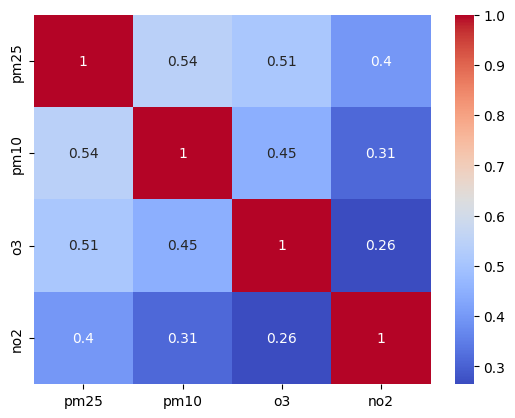

In [5]:
corr = data.drop('date', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

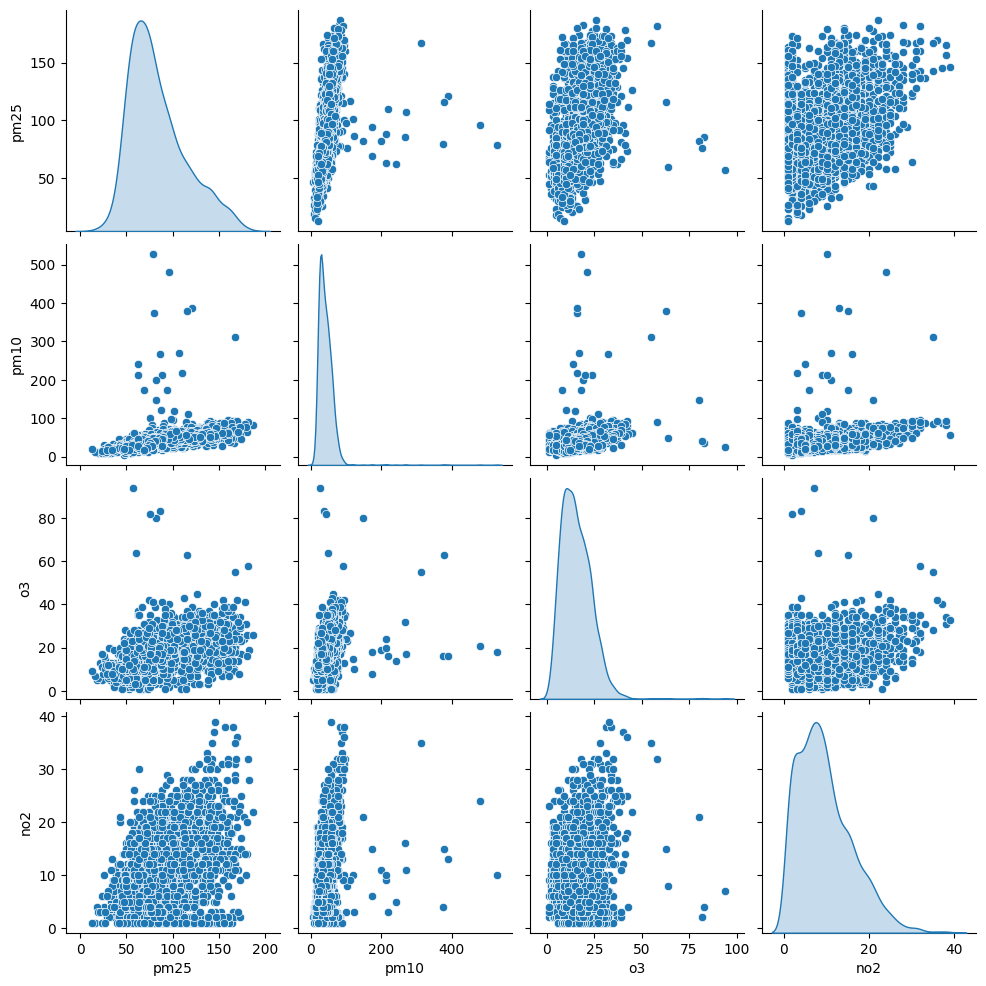

In [6]:
sns.pairplot(data.drop('date', axis=1), diag_kind='kde')

# Find Autocorrelation

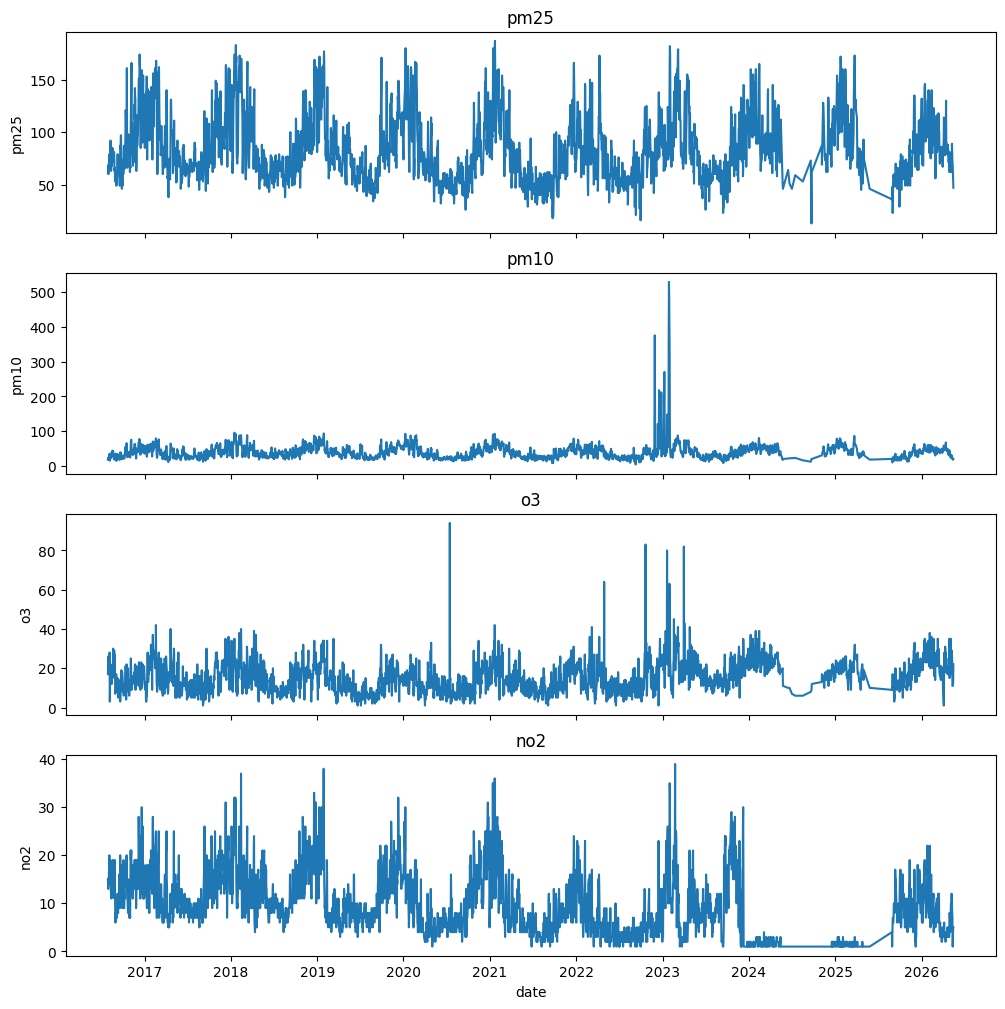

In [7]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    sns.lineplot(x='date', y=item, data=data, ax=axs[i])
    axs[i].set_title(item)

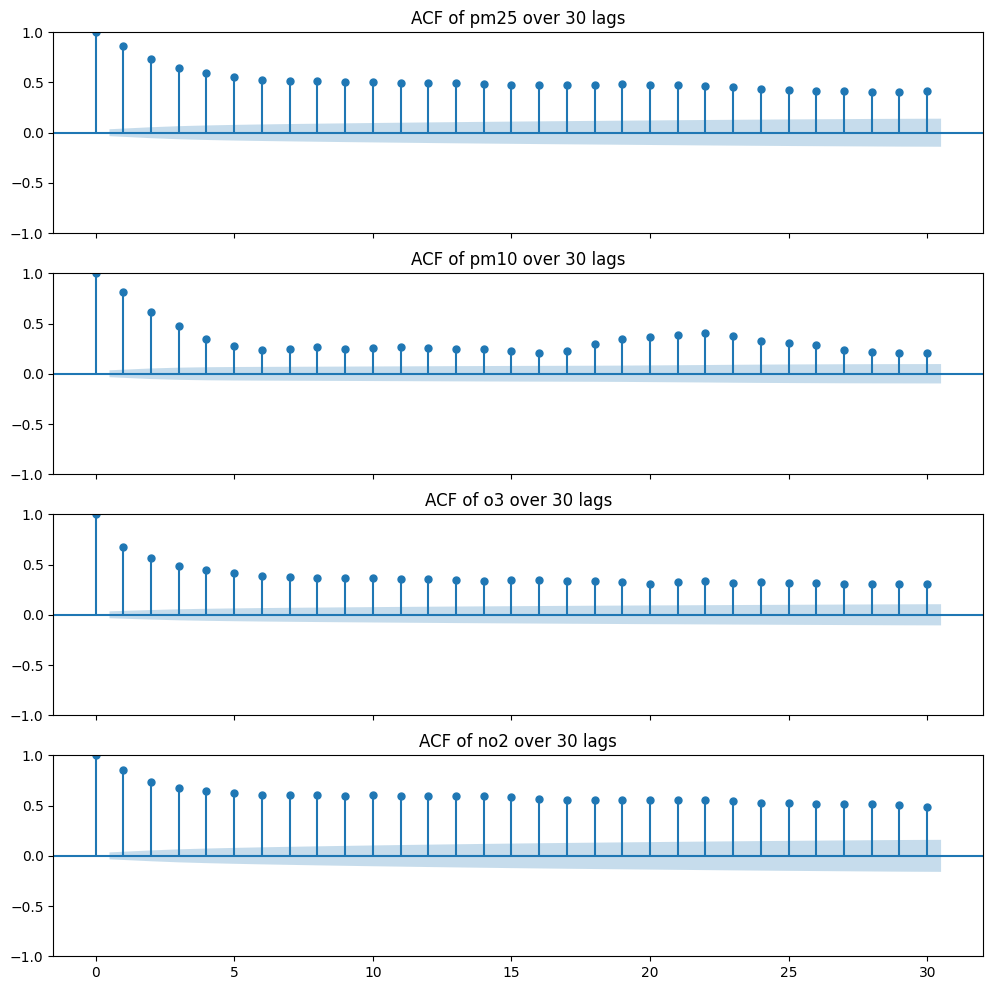

In [8]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    plot_acf(data[item], lags=30,alpha=0.05, title=f'ACF of {item} over 30 lags', ax=axs[i])
plt.show()

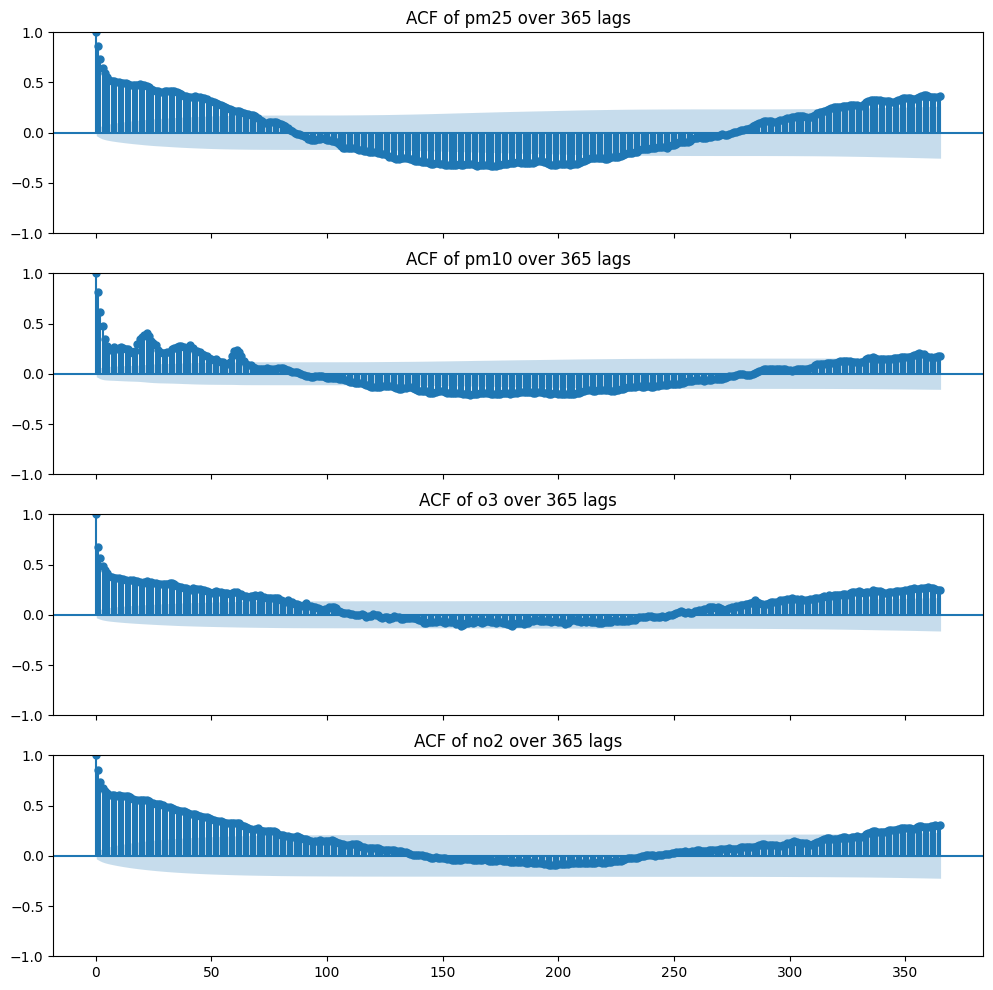

In [9]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    plot_acf(data[item], lags=365,alpha=0.05, title=f'ACF of {item} over 365 lags', ax=axs[i])
plt.show()

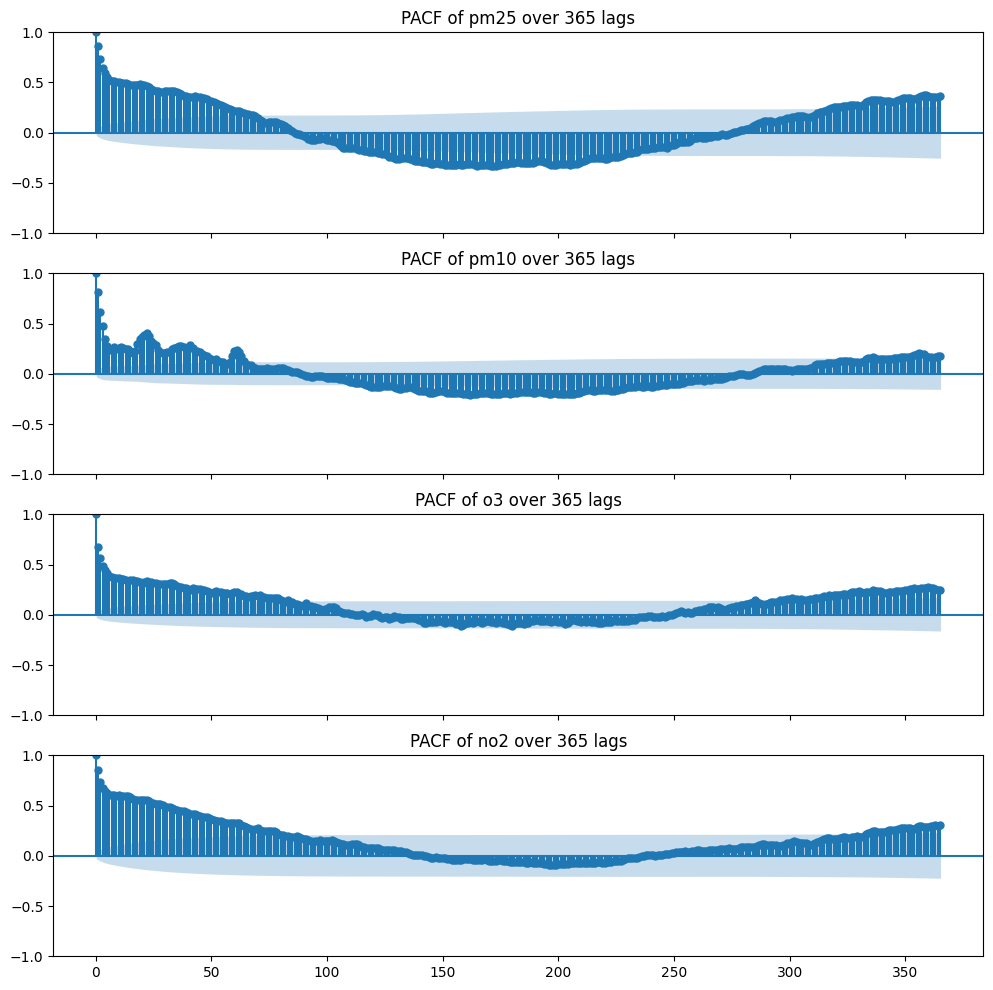

In [10]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    plot_acf(data[item], lags=365,alpha=0.05, title=f'PACF of {item} over 365 lags', ax=axs[i])
plt.show()

# Boxplots

## Display boxplots by year

Text(0.5, 0, 'Year')

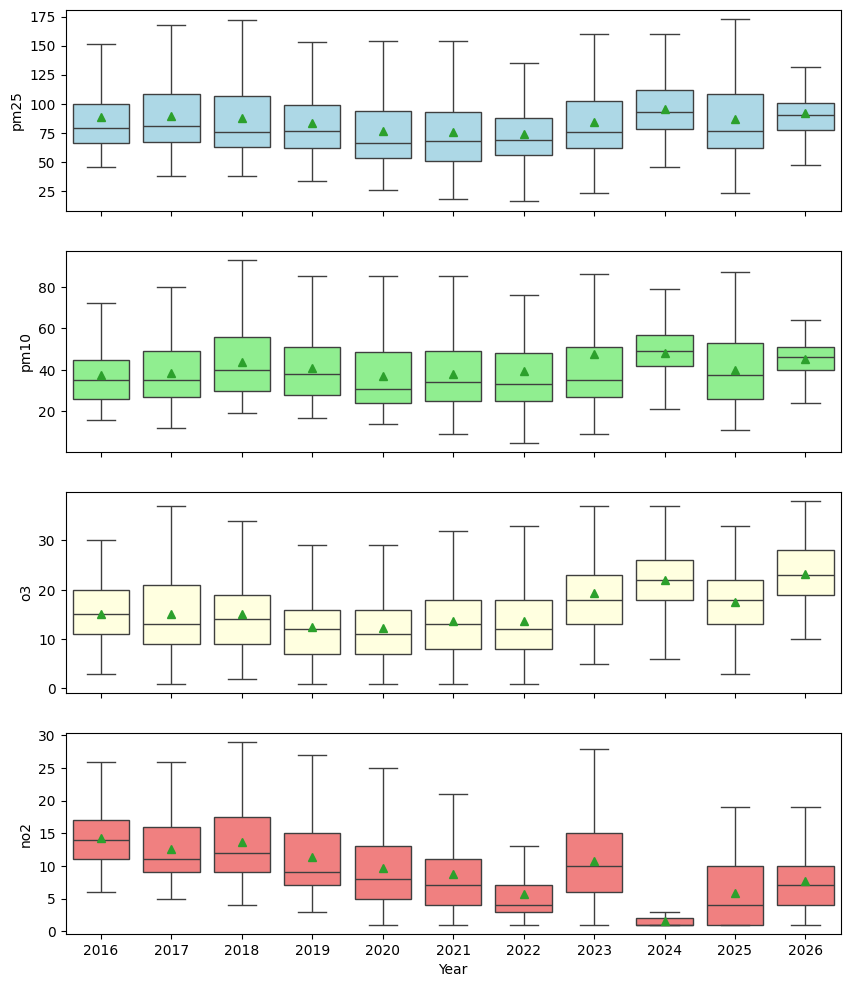

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(10, 3*4),sharex=True)

sns.boxplot(x=data['date'].dt.year, y=data['pm25'], ax=axes[0], showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
sns.boxplot(x=data['date'].dt.year, y=data['pm10'], ax=axes[1], showfliers=False, showmeans=True, boxprops={'facecolor':'lightgreen'})
sns.boxplot(x=data['date'].dt.year, y=data['o3'], ax=axes[2], showfliers=False, showmeans=True, boxprops={'facecolor':'lightyellow'})
sns.boxplot(x=data['date'].dt.year, y=data['no2'], ax= axes[3], showfliers=False, showmeans=True, boxprops={'facecolor':'lightcoral'})
plt.xlabel("Year")

## Display boxplots by month

Text(0.5, 0, 'Month')

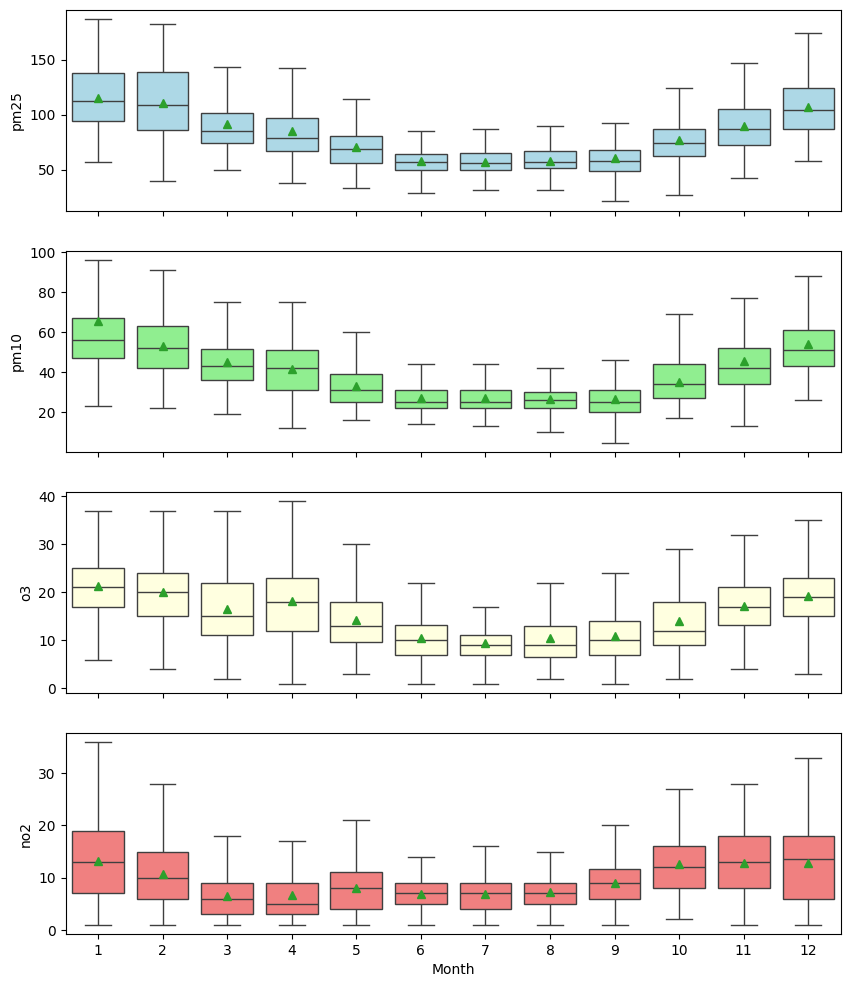

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(10, 3*4),sharex=True)

sns.boxplot(x=data['date'].dt.month, y=data['pm25'], ax=axes[0], showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
sns.boxplot(x=data['date'].dt.month, y=data['pm10'], ax=axes[1], showfliers=False, showmeans=True, boxprops={'facecolor':'lightgreen'})
sns.boxplot(x=data['date'].dt.month, y=data['o3'], ax=axes[2], showfliers=False, showmeans=True, boxprops={'facecolor':'lightyellow'})
sns.boxplot(x=data['date'].dt.month, y=data['no2'], ax= axes[3], showfliers=False, showmeans=True, boxprops={'facecolor':'lightcoral'})
plt.xlabel("Month")

## Display histograms and boxplots of PM2.5 by quarter

Text(0.5, 0.98, 'PM2.5 Distribution by Quarter')

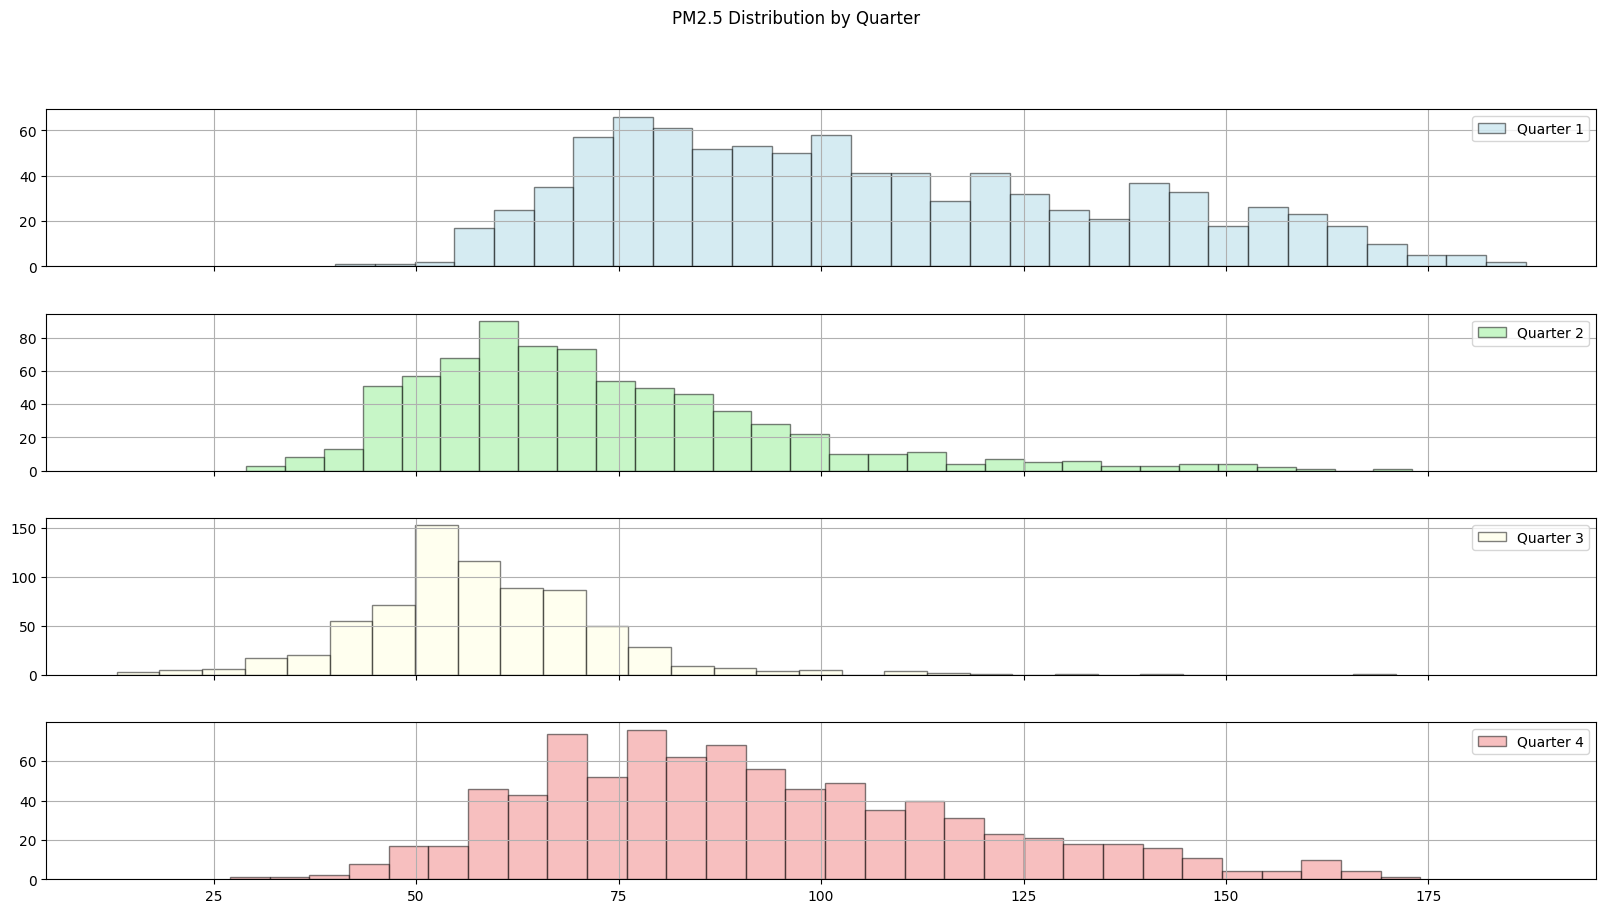

In [13]:
fig, axs = plt.subplots(4,1, figsize=(20,10), sharex=True)

colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for quarter, group in data.groupby(data['date'].dt.quarter):
    group.hist("pm25", bins=30, color=colors[quarter-1], edgecolor='black', ax=axs[quarter-1], label=f"Quarter {quarter}",alpha=0.5)
    axs[quarter-1].set_title(None)
    axs[quarter-1].legend()

fig.suptitle("PM2.5 Distribution by Quarter")

Text(0.5, 0, 'Quarter')

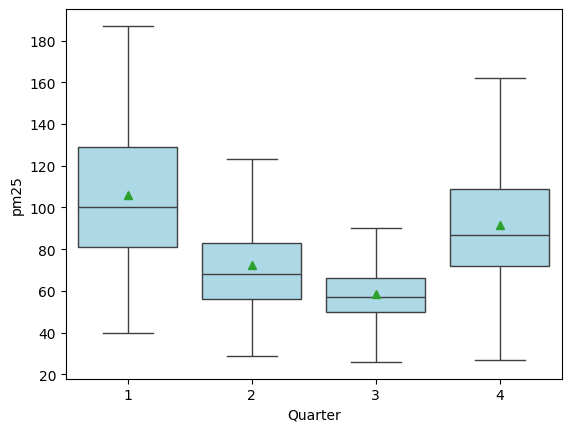

In [14]:
fig, ax = plt.subplots(1, 1)

sns.boxplot(x=data['date'].dt.quarter, y=data['pm25'], ax=ax, showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
plt.xlabel("Quarter")

## Display histograms and boxplots of PM2.5 by Seasons

Text(0.5, 0.98, 'PM2.5 Distribution by Season')

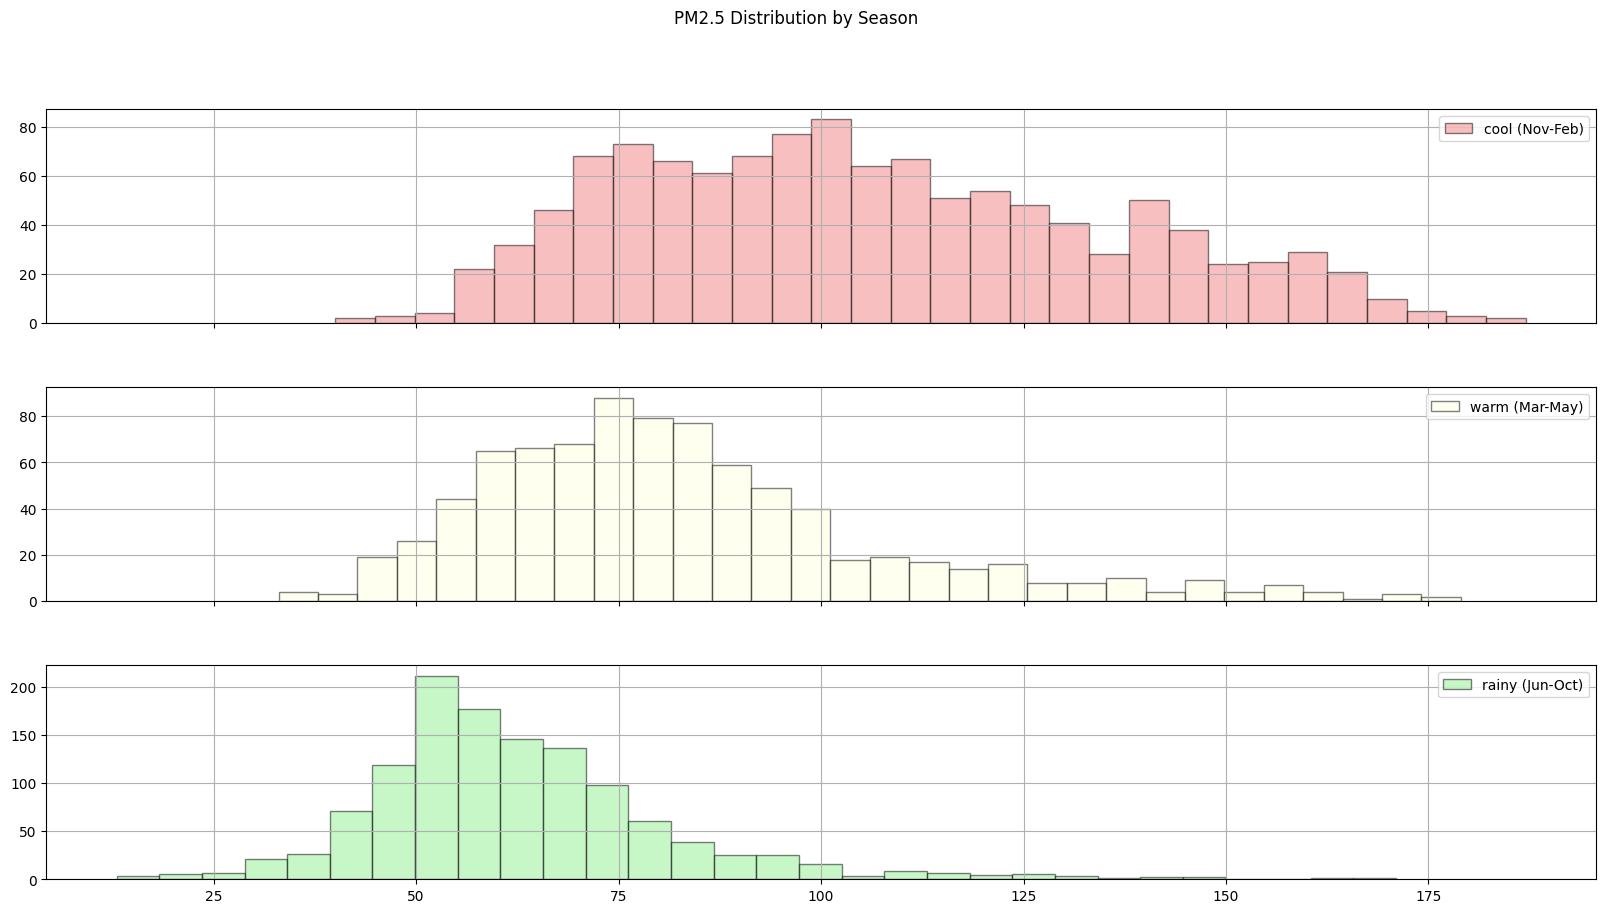

In [15]:
fig, axs = plt.subplots(3,1, figsize=(20,10), sharex=True)

colors = ['lightcoral', 'lightyellow', 'lightgreen']
get_season = lambda x: 1 if x.month in [11, 12, 1, 2] else 2 if x.month in [3, 4, 5] else 3
seasons = ["cool (Nov-Feb)", "warm (Mar-May)", "rainy (Jun-Oct)"]

for season, group in data.groupby(data.date.map(get_season)):
    group.hist("pm25", bins=30, color=colors[season-1], edgecolor='black', ax=axs[season-1], label=f"{seasons[season-1]}",alpha=0.5)
    axs[season-1].set_title(None)
    axs[season-1].legend()

fig.suptitle("PM2.5 Distribution by Season")

Text(0.5, 0, 'Season')

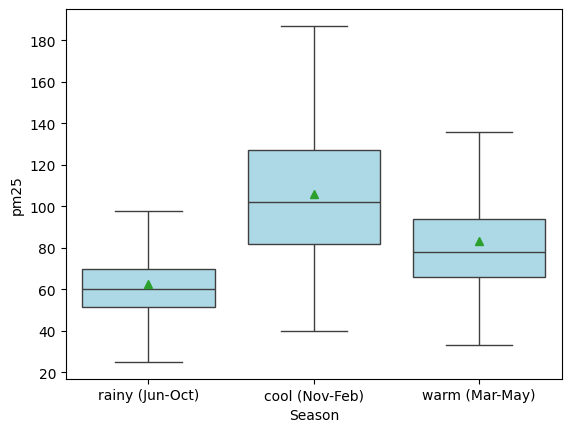

In [16]:
fig, ax = plt.subplots(1,1)

seasons = ["cool (Nov-Feb)", "warm (Mar-May)", "rainy (Jun-Oct)"]
grouped_by_season = data.date.map(get_season).map(lambda x: seasons[x-1])


sns.boxplot(x=grouped_by_season, y=data['pm25'], ax=ax, showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
plt.xlabel("Season")

# Time series decomposition

In [17]:
results = seasonal_decompose(data['pm25'], model='multiplicative', period=365)
trend = results.trend
seasonal = results.seasonal
resid = results.resid

<Axes: xlabel='date', ylabel='resid'>

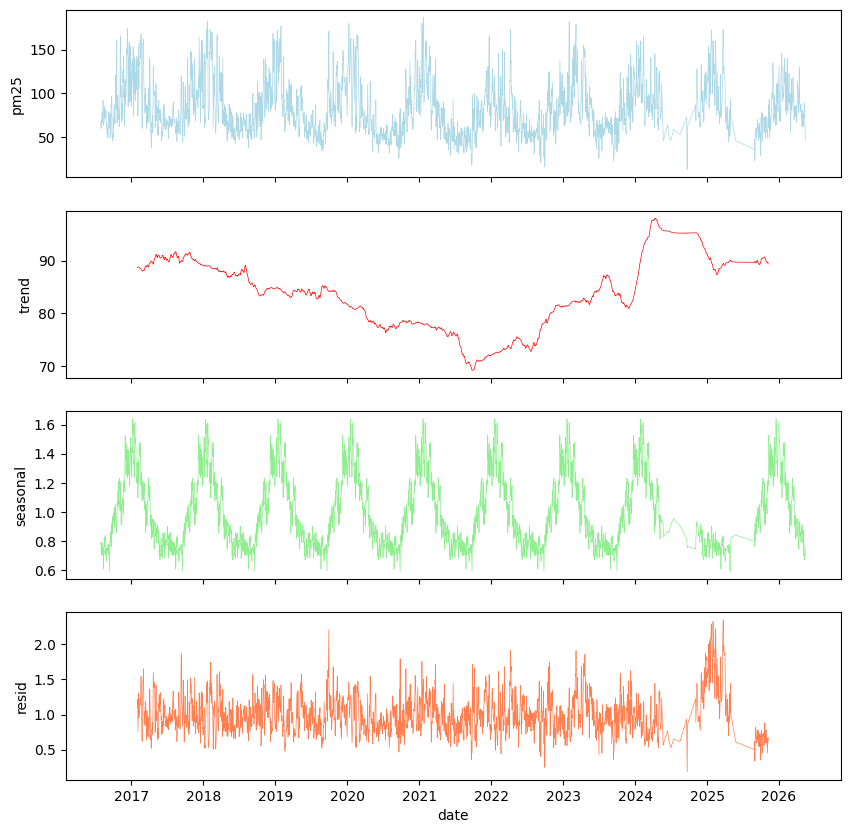

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

sns.lineplot(x=data['date'], y=data['pm25'], ax=axes[0], linewidth=0.5,color='lightblue')
sns.lineplot(x=data['date'], y=trend, ax=axes[1], linewidth=0.5,color='red')
sns.lineplot(x=data['date'], y=seasonal, ax=axes[2], linewidth=0.5,color='lightgreen')
sns.lineplot(x=data['date'], y=resid, ax=axes[3], linewidth=0.5,color='coral')

# Forecasting with ARIMA

In [19]:
import statsmodels.tsa.arima.model as arima

In [20]:
T = 90
train, test = data['pm25'][:-T], data['pm25'][-T:]

In [21]:
arima_model = arima.ARIMA(train, order=(1,0,7),seasonal_order=(1,1,1,90))
model_fit = arima_model.fit()
forecast = model_fit.get_forecast(steps=len(test))

In [22]:
mean_forecast = pd.Series(forecast.predicted_mean)
mean_forecast.index = index=data['date'].iloc[-T:]

In [23]:
lower = forecast.conf_int(alpha=0.5).iloc[:,0]
upper = forecast.conf_int(alpha=0.5).iloc[:,1]

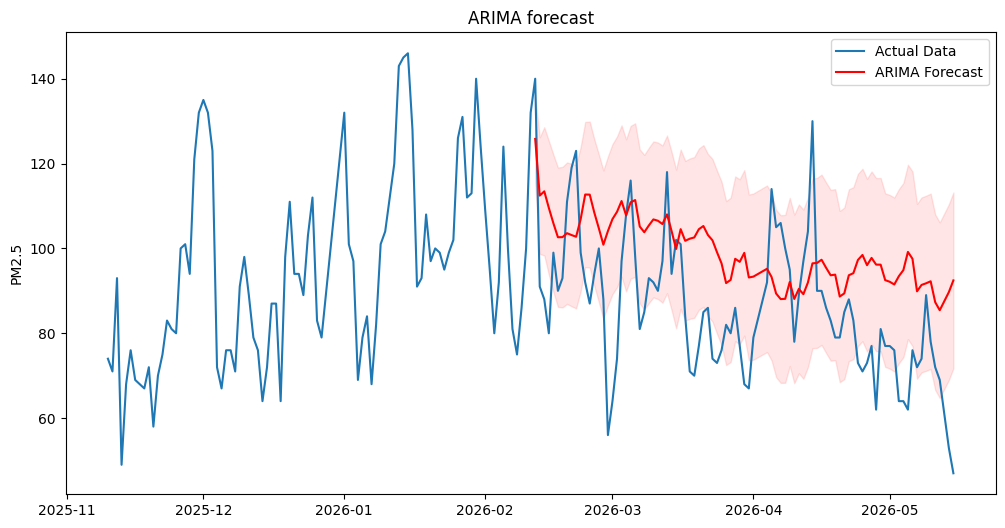

In [24]:
plt.figure(figsize=(12,6))
plt.plot(data['date'].iloc[-T*2:], data['pm25'].iloc[-T*2:],label="Actual Data")
plt.plot(mean_forecast.index, mean_forecast.values, label="ARIMA Forecast", color='red')

plt.fill_between(data['date'].iloc[-T:], 
                 lower,
                 upper,
                 color='red', alpha=.1)

plt.title("ARIMA forecast")
plt.ylabel("PM2.5")
plt.legend()

# Forecasting with RNN

In [25]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.optim import Adam

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"

In [26]:
class rnn(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(rnn, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [27]:
# Scaling
scaler = MinMaxScaler()

pm25_data = data['pm25'].values.reshape(-1, 1)
scaler.fit(pm25_data[:-T])

train = pm25_data[:-T]

scaled_data = scaler.transform(train)

train_input = np.zeros((len(scaled_data)-90-T, 90, 1))
for i in range(len(scaled_data)-90-T):
    train_input[i] = scaled_data[i:i+90]
train_output = scaled_data[90:-T]

test_input = np.zeros((T, 90, 1))
for i in range(T):
    test_input[i] = scaled_data[len(scaled_data)-T-90+i:len(scaled_data)-T+i]
test_output = scaled_data[len(scaled_data)-T:]

In [28]:
train_input.shape, train_output.shape, test_input.shape, test_output.shape

((2952, 90, 1), (2952, 1), (90, 90, 1), (90, 1))

In [29]:
input_size = 1
hidden_size = 64
num_layers = 1
output_size = 1
epochs = 100
model = rnn(input_size, hidden_size, num_layers, output_size).to(device)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [30]:
training_loss = []
for epoch in range(epochs):
    model.train()
    batch_size = 256

    epoch_loss = 0
    for i in range(0, len(train_input)-1, batch_size):
        inputs = torch.tensor(train_input[i:i+batch_size], dtype=torch.float32).to(device)
        targets = torch.tensor(train_output[i:i+batch_size], dtype=torch.float32).to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        epoch_loss += loss.item()
    
    training_loss.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 1/100, Loss: 2.8736
Epoch 2/100, Loss: 2.3929
Epoch 3/100, Loss: 1.9647
Epoch 4/100, Loss: 1.5759
Epoch 5/100, Loss: 1.2217
Epoch 6/100, Loss: 0.9043
Epoch 7/100, Loss: 0.6330
Epoch 8/100, Loss: 0.4257
Epoch 9/100, Loss: 0.3105
Epoch 10/100, Loss: 0.3103
Epoch 11/100, Loss: 0.3746
Epoch 12/100, Loss: 0.4055
Epoch 13/100, Loss: 0.3837
Epoch 14/100, Loss: 0.3397
Epoch 15/100, Loss: 0.3025
Epoch 16/100, Loss: 0.2848
Epoch 17/100, Loss: 0.2862
Epoch 18/100, Loss: 0.3007
Epoch 19/100, Loss: 0.3213
Epoch 20/100, Loss: 0.3428
Epoch 21/100, Loss: 0.3612
Epoch 22/100, Loss: 0.3745
Epoch 23/100, Loss: 0.3816
Epoch 24/100, Loss: 0.3826
Epoch 25/100, Loss: 0.3780
Epoch 26/100, Loss: 0.3686
Epoch 27/100, Loss: 0.3556
Epoch 28/100, Loss: 0.3404
Epoch 29/100, Loss: 0.3241
Epoch 30/100, Loss: 0.3081
Epoch 31/100, Loss: 0.2932
Epoch 32/100, Loss: 0.2804
Epoch 33/100, Loss: 0.2700
Epoch 34/100, Loss: 0.2622
Epoch 35/100, Loss: 0.2566
Epoch 36/100, Loss: 0.2527
Epoch 37/100, Loss: 0.2500
Epoch 38/1

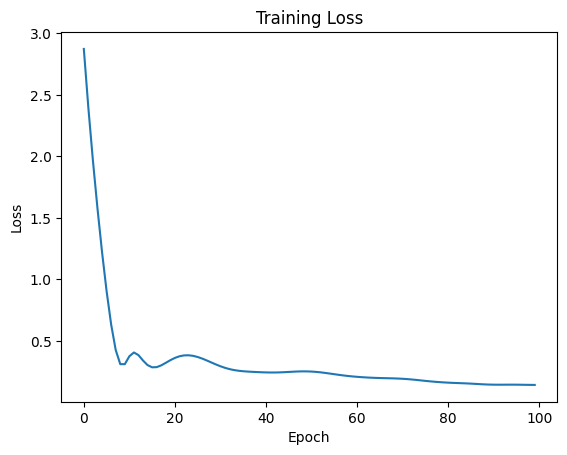

In [31]:
plt.plot(training_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [32]:
pred_y = model(torch.tensor(test_input, dtype=torch.float32).to(device)).cpu().detach().numpy()
pred_y = scaler.inverse_transform(pred_y)

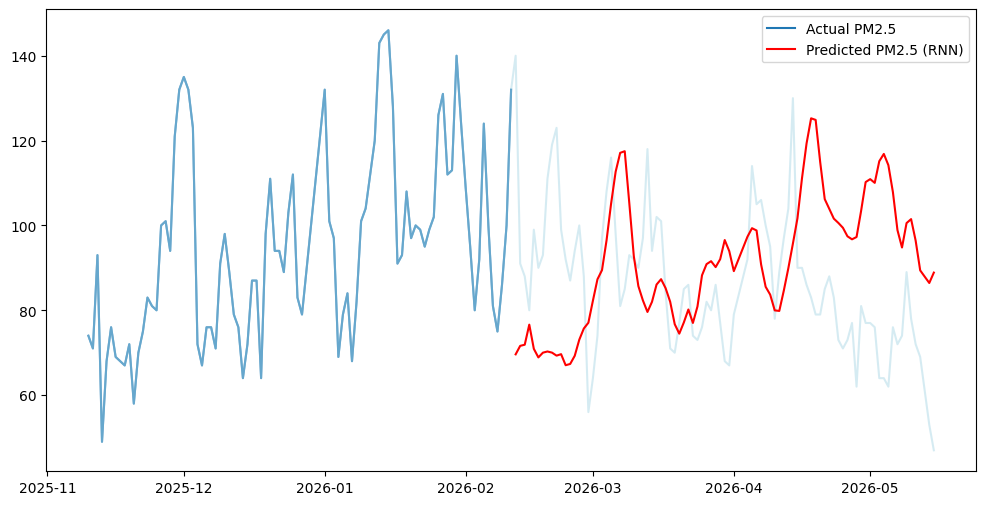

In [33]:
date = data['date']

plt.figure(figsize=(12,6))
plt.plot(date[-T*2:-T], pm25_data[-T*2:-T], label="Actual PM2.5")
plt.plot(date[-T*2:], pm25_data[-T*2:], label=None, color='lightblue', alpha=0.5)
plt.plot(date[-T:], pred_y, label="Predicted PM2.5 (RNN)", color='red')
plt.legend()
plt.show()